# IEMS 490 Wave Training
Trains an open source version of Google's Wavenet architecture to fit our 'waves' from our LaserPowerCurrent and SignalPdInGaAs variables

In [1]:
import torch
from torch_fn.wavenet_lstm import lr_schedule, WaveNet_LSTM #LSTM of WaveNet
from torch_fn.wavenet2 import WaveNet # Normal WaveNet, likely from the paper. Need someone who is literate to check.
import h5py
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import torch.nn as nn
import torch.optim as optim

### For each time step in each file, get the Laser Power and Signal
We don't want to use X, Y because that can change in each layer

In [2]:
folder_path = './DATASET' # Replace with your folder path
# This creates a list of extensions (including the dot)
file_paths = [f for f in Path(folder_path).iterdir() if f.is_file() and f.suffix == '.hdf5']

print(file_paths)

[WindowsPath('DATASET/layer1.hdf5'), WindowsPath('DATASET/layer10.hdf5'), WindowsPath('DATASET/layer100.hdf5'), WindowsPath('DATASET/layer101.hdf5'), WindowsPath('DATASET/layer102.hdf5'), WindowsPath('DATASET/layer103.hdf5'), WindowsPath('DATASET/layer104.hdf5'), WindowsPath('DATASET/layer105.hdf5'), WindowsPath('DATASET/layer106.hdf5'), WindowsPath('DATASET/layer107.hdf5'), WindowsPath('DATASET/layer108.hdf5'), WindowsPath('DATASET/layer109.hdf5'), WindowsPath('DATASET/layer11.hdf5'), WindowsPath('DATASET/layer110.hdf5'), WindowsPath('DATASET/layer111.hdf5'), WindowsPath('DATASET/layer112.hdf5'), WindowsPath('DATASET/layer113.hdf5'), WindowsPath('DATASET/layer114.hdf5'), WindowsPath('DATASET/layer115.hdf5'), WindowsPath('DATASET/layer116.hdf5'), WindowsPath('DATASET/layer117.hdf5'), WindowsPath('DATASET/layer118.hdf5'), WindowsPath('DATASET/layer119.hdf5'), WindowsPath('DATASET/layer12.hdf5'), WindowsPath('DATASET/layer120.hdf5'), WindowsPath('DATASET/layer121.hdf5'), WindowsPath('DAT

In [3]:
file1 = h5py.File(file_paths[0], 'r')
file1

<HDF5 file "layer1.hdf5" (mode r)>

In [30]:
xs, ys = file1['OpenData'][0], file1['OpenData'][1]
x_dict, y_dict = {}, {}
n=1
for i in range(len(xs)):
    if round(xs[i],n) not in x_dict.keys():
        x_dict[round(xs[i],n)] = 1
    else:
        x_dict[round(xs[i],n)] += 1
    if round(ys[i],n) not in y_dict.keys():
        y_dict[round(ys[i],n)] = 1
    else:
        y_dict[round(ys[i],n)] += 1
vals = []
for x_val in x_dict.keys():
    vals.append(x_dict[x_val])
print(len(vals))
vals = []
for y_val in y_dict.keys():
    vals.append(y_dict[y_val])
print(len(vals))

94
94


In [31]:
coords = []
for x in x_dict.keys():
    for y in y_dict.keys():
        # Set as tuples rather than lists because we don't need to alter afterwards
        coords.append((x,y))

#### Will take a long time (sad) [maybe 5 minutes]
Will save this as an .npz file bc we're not doing this again unless we're changing the coordinates

In [32]:
#data = []
lazer_data = []
signal_data = []
for file in file_paths:
    file_info = h5py.File(file, 'r')
    file_data = file_info['OpenData']
    xs, ys, lazer, signal = file_data[0], file_data[1], file_data[5], file_data[6]
    #x_dict, y_dict= {}, {}
    lazer_dict, signal_dict = {}, {}
    for i in range(len(xs)):
        new_coords = (round(xs[i], 1), round(ys[i],1))
        if new_coords not in lazer_dict.keys():
            lazer_dict[new_coords] = [lazer[i]]
            signal_dict[new_coords] = [signal[i]]
        else:
            lazer_dict[new_coords].append(lazer[i])
            #lazer_dict[new_coords][1]+=1
            signal_dict[new_coords].append(signal[i])
            #signal_dict[new_coords][1]+=1
    lazer_data.append(lazer_dict)
    signal_data.append(signal_dict)


In [33]:
median_lazer = []
median_signal = []
for i in range(len(lazer_data)):
    l_dict, s_dict = lazer_data[i], signal_data[i]
    
    # Process all coordinates for this file in one go
    batch_l = [np.median(l_dict[c]) if c in l_dict else 0 for c in coords]
    batch_s = [np.median(s_dict[c]) if c in s_dict else 0 for c in coords]
    
    median_lazer.append(batch_l)
    median_signal.append(batch_s)

In [41]:
np.savez('my_arrays.npz', arr_a=np.array(median_lazer), arr_b=np.array(median_signal))

### All data should now be the same length

In [3]:
# Load the data from the .npz file
npz_file = np.load('my_arrays.npz')

# Access individual arrays
median_lazer = npz_file['arr_a']
median_signal = npz_file['arr_b']

# Optional: check the names of all arrays in the file
print(f"Arrays in file: {npz_file.files}")

# Close the NpzFile object
npz_file.close()


Arrays in file: ['arr_a', 'arr_b']


In [4]:
median_lazer.shape

(379, 8836)

In [5]:
# 1. Combine lists into a single NumPy array (Shape: N x 2)
# This is significantly faster than a list comprehension for large data
all_data = np.stack([median_lazer, median_signal], axis=1)

# 2. Split the NumPy array directly
train_x, test_x = train_test_split(all_data, test_size=0.6, shuffle=True)

# 3. Convert directly to Tensors
# .float() ensures they are float32, which most PyTorch models expect
x_train_tensor = torch.from_numpy(train_x).float()
x_test_tensor  = torch.from_numpy(test_x).float()
print(f"Train Tensor Shape: {x_train_tensor.shape}")
print(f"Test Tensor Shape:  {x_test_tensor.shape}")

# 4. Create Dataset and Loader
# Using (x, x) for Autoencoder style or self-supervised training
train_dataset = TensorDataset(x_train_tensor, x_train_tensor)
test_dataset  = TensorDataset(x_test_tensor, x_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train Tensor Shape: torch.Size([151, 2, 8836])
Test Tensor Shape:  torch.Size([228, 2, 8836])


In [6]:
for batch, _ in train_loader:
    print(batch.shape)

torch.Size([32, 2, 8836])
torch.Size([32, 2, 8836])
torch.Size([32, 2, 8836])
torch.Size([32, 2, 8836])
torch.Size([23, 2, 8836])


### Train model

In [ ]:
def train(model, dataloader, valid_dataloader, epochs = 10, lr=1e-3):
    #model.train()
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    train_losses = []
    valid_losses = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch, _ in dataloader:
            outputs = model(batch)
            optimizer.zero_grad()
            loss = criterion(outputs, batch)
            loss.backward()
            optimizer.step()
            train_loss+= loss.item() * batch.size(0)
        epoch_loss = train_loss / len(dataloader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")
        train_losses.append(train_loss)
        valid_losses.append(test(model, valid_dataloader))
    return train_losses, valid_losses

def test(model, dataloader):
    model.eval()
    test_loss = 0
    criterion = nn.MSELoss()
    with torch.no_grad():
       for batch, _ in dataloader:
          #batch = batch.permute(0,2,1).float()
          outputs = model(batch)
          loss = criterion(batch, outputs)
          test_loss += loss.item() * batch.size(0)
    print(f"Test loss: {test_loss:.4f}")
    return test_loss


In [13]:
from torch_fn.wavenet2 import WaveNet
wave_model = WaveNet(input_size=2, out_channels=32, kernel_size=3, n=1)
train_loss, valid_loss = train(wave_model, train_loader, test_loader, epochs = 250)

Epoch [1/250], Loss: 6514430.3609
Test loss: 1478088004.0000
Epoch [2/250], Loss: 6513997.5397
Test loss: 1477999118.0000
Epoch [3/250], Loss: 6513590.7285
Test loss: 1477895476.0000
Epoch [4/250], Loss: 6513120.1689
Test loss: 1477783406.0000
Epoch [5/250], Loss: 6512542.6755
Test loss: 1477623814.0000
Epoch [6/250], Loss: 6511791.5397
Test loss: 1477431416.0000
Epoch [7/250], Loss: 6510858.0166
Test loss: 1477182126.0000
Epoch [8/250], Loss: 6509622.7881
Test loss: 1476845576.0000
Epoch [9/250], Loss: 6507992.4272
Test loss: 1476422760.0000
Epoch [10/250], Loss: 6505874.5861
Test loss: 1475833322.0000
Epoch [11/250], Loss: 6503110.6821
Test loss: 1475141494.0000
Epoch [12/250], Loss: 6499722.8344
Test loss: 1474272764.0000
Epoch [13/250], Loss: 6495738.6093
Test loss: 1473255970.0000
Epoch [14/250], Loss: 6490858.0033
Test loss: 1472044896.0000
Epoch [15/250], Loss: 6485124.3179
Test loss: 1470556400.0000
Epoch [16/250], Loss: 6478142.8510
Test loss: 1468827252.0000
Epoch [17/250], L

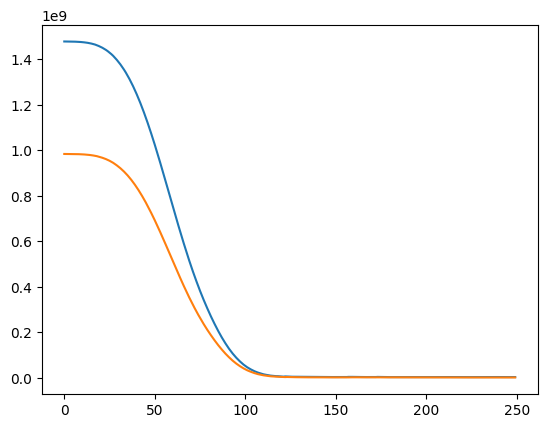

In [15]:
import matplotlib.pyplot as plt
plt.plot(valid_loss)
plt.plot(train_loss)
plt.show()

In [19]:
PATH = "model_weights.pth"
torch.save(wave_model.state_dict(), PATH)

### We might be able to train BERT like encoder to fill in the blanks